# Explorotary Data Analysis for Animal Detection Dataset

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image

## Basic information

In [3]:
dataset_path = Path("data")

train_images = list((dataset_path / "train").rglob("*.jpg"))
test_images = list((dataset_path / "test").rglob("*.jpg"))

print(f"Train images: {len(train_images)}")
print(f"Test images: {len(test_images)}")
print(f"Total images: {len(train_images) + len(test_images)}")

Train images: 22566
Test images: 6505
Total images: 29071


In [4]:
dataset_path = Path("data")

total = 0

for split in ["train", "test"]:
    split_path = dataset_path / split
    print(f"\n{split.upper()}")

    split_total = 0

    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            images = list(class_dir.glob("*.jpg"))
            count = len(images)

            print(f"{class_dir.name:15} {count}")

            split_total += count

    print(f"Total {split}: {split_total}")

    total += split_total

print(f"\nTOTAL DATASET: {total}")


TRAIN
Bear            87
Brown bear      108
Bull            47
Butterfly       1875
Camel           67
Canary          113
Caterpillar     494
Cattle          70
Centipede       194
Cheetah         132
Chicken         388
Crab            309
Crocodile       108
Deer            327
Duck            542
Eagle           719
Elephant        155
Fish            835
Fox             148
Frog            588
Giraffe         298
Goat            202
Goldfish        133
Goose           289
Hamster         64
Harbor seal     240
Hedgehog        80
Hippopotamus    76
Horse           400
Jaguar          100
Jellyfish       457
Kangaroo        98
Koala           56
Ladybug         392
Leopard         123
Lion            208
Lizard          1200
Lynx            80
Magpie          61
Monkey          770
Moths and butterflies 1429
Mouse           151
Mule            61
Ostrich         136
Otter           75
Owl             406
Panda           91
Parrot          421
Penguin         377
Pig             19

In [5]:
data = []

for split in ["train", "test"]:
    for class_dir in (dataset_path / split).iterdir():
        if class_dir.is_dir():
            count = len(list(class_dir.glob("*.jpg")))
            data.append({
                "split": split,
                "class": class_dir.name,
                "count": count
            })

df = pd.DataFrame(data)
df

,split,class,count
0,train,Bear,87
1,train,Brown bear,108
2,train,Bull,47
3,train,Butterfly,1875
4,train,Camel,67
...,...,...,...
155,test,Turtle,5
156,test,Whale,52
157,test,Woodpecker,32
158,test,Worm,15


## Class Distribution

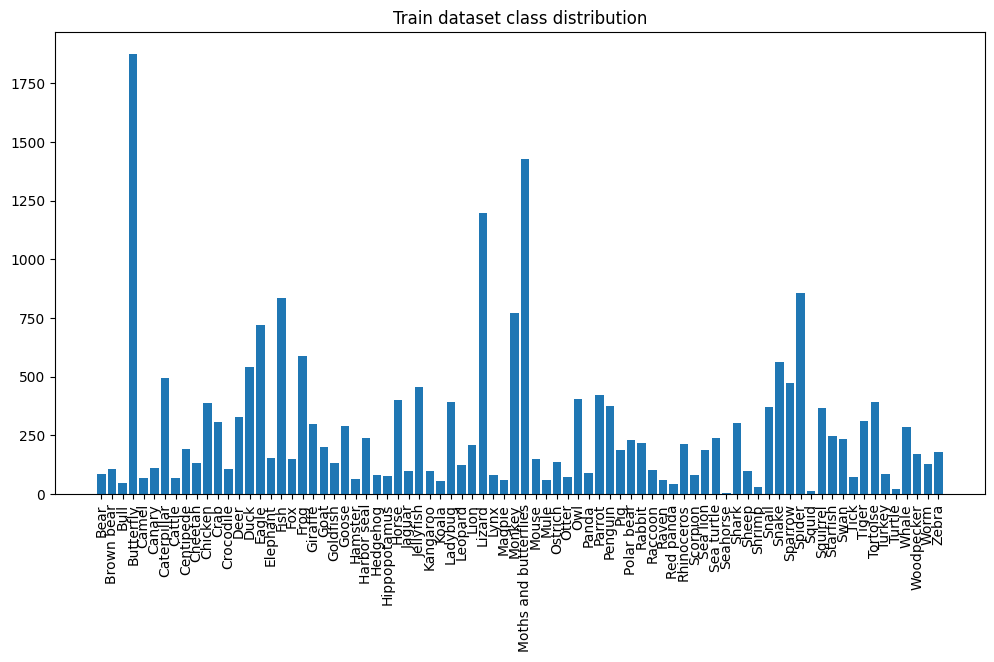

In [6]:
train_df = df[df["split"] == "train"]

plt.figure(figsize=(12,6))
plt.bar(train_df["class"], train_df["count"])
plt.xticks(rotation=90)
plt.title("Train dataset class distribution")
plt.show()

## Overview of Random Pictures

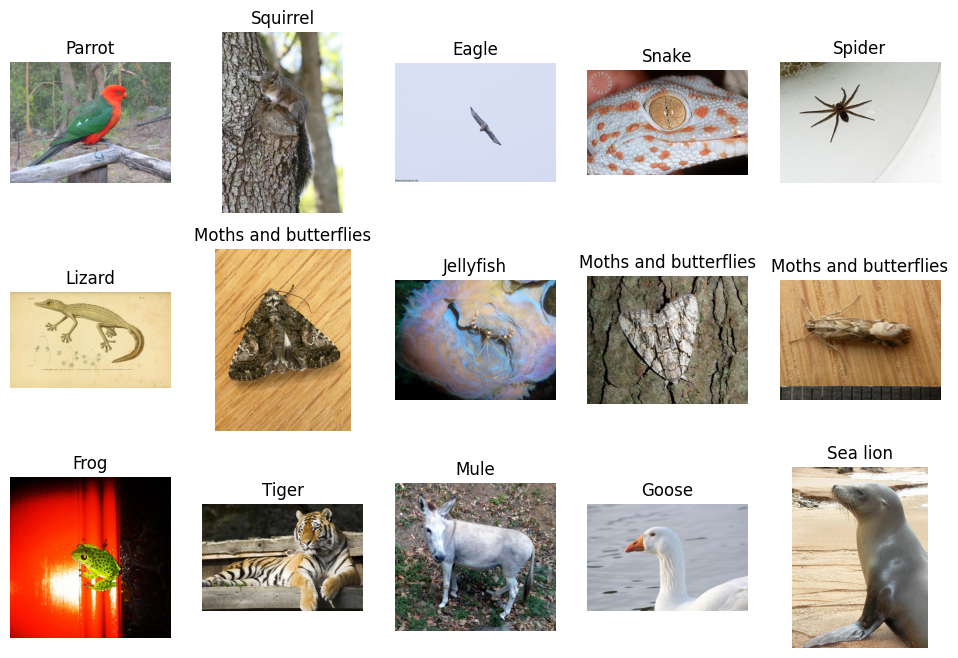

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(12,8))

for ax in axes.flat:
    img_path = random.choice(train_images)
    img = Image.open(img_path)
    
    ax.imshow(img)
    ax.set_title(img_path.parent.name)
    ax.axis("off")

plt.show()

## Basic Image Statistics

In [8]:
sizes = []

for img_path in train_images[:500]:
    img = Image.open(img_path)
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=["width","height"])

sizes_df.describe()

,width,height
count,500.000000,500.000000
mean,989.372000,781.786000
std,93.059367,134.861007
min,591.000000,384.000000
25%,1024.000000,683.000000
50%,1024.000000,768.000000
75%,1024.000000,824.750000
max,1024.000000,1024.000000


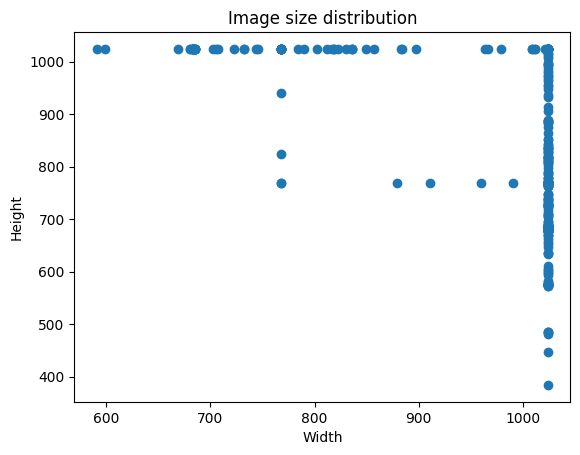

In [9]:
plt.scatter(sizes_df["width"], sizes_df["height"])
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image size distribution")
plt.show()

In [10]:
bad_images = []

for img_path in train_images:
    try:
        Image.open(img_path).verify()
    except:
        bad_images.append(img_path)

print(f"Broken images: {len(bad_images)}")

Broken images: 0


In [11]:
pixels = []

for img_path in train_images[:200]:
    img = Image.open(img_path).convert("RGB")
    pixels.append(np.array(img))

pixels = np.concatenate([p.reshape(-1,3) for p in pixels])

print("Mean:", pixels.mean(axis=0))
print("Std:", pixels.std(axis=0))

Mean: [124.07290574 120.92505042 107.26561546]
Std: [69.38575617 68.4573516  68.25485825]
